In [30]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage,HumanMessage
import operator

In [31]:
generator_llm=ChatOpenAI(model='gpt-4o-mini')
evaluator_llm=ChatOpenAI(model='gpt-4o-mini')
optimizer_llm=ChatOpenAI(model='gpt-4o-mini')

In [32]:
class TweetEvaluation(BaseModel):
    evaluation:Literal["approved","needs_improvement"]=Field(...,description="Final Evaluation result")
    feedback:str=Field(...,description="feedback for the tweet.")

In [33]:
structured_evaluator_llm=evaluator_llm.with_structured_output(TweetEvaluation)

In [34]:
#state
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved","need_improvements"]
    feedback:str
    iteration:int
    max_iteration:int

    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]

In [35]:
def generate_tweet(state:TweetState):
    #prompt
    messages=[
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        write a short,original, and hilarious tweet on the topic :"{state['topic']}".
        Rules:
        -Do Not use question-answer format.
        -Max 280 characters.
        - use observational humor,irony,sarcasm, or cultural references.
        - Think in meme logic,punchlines,or relatable takes.
        -Use simple ,day to day english
""")
    ]
    response=generator_llm.invoke(messages).content
    return {'tweet':response,'tweet_history':[response]}

In [36]:
def evaluate_tweet(state:TweetState):
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}


In [37]:
def optimize_tweet(state:TweetState):
    messages=[
        SystemMessage(content="You punch up tweets for virality and humor based on feedback"),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
                     "{state['feedback']}"
        Topic:"{state['topic']}"
        original Tweet:
        {state['tweet']}
        re-write it as a short,viral-worthy tweet.Avoid Q&A style and stay under 280 characters.
""")
    ]
    response=optimizer_llm.invoke(messages).content
    iteration=state['iteration'] +1
    return {'tweet':response,'iteration':iteration,'tweet_history':[response]}
    

In [38]:
def route_evaluation(state:TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

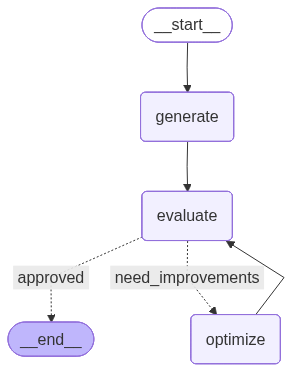

In [39]:
graph=StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved':END,'need_improvements':'optimize'})
graph.add_edge('optimize','evaluate')

workflow=graph.compile()
workflow




In [42]:
initail_state={
    'topic':"trump",
    "iteration":1,
    "max_iteration":5
}
workflow.invoke(initail_state)

/home/motherson/Documents/Langgraph-demo/.venv/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TweetEvaluation(evaluatio...and humorous critique."), input_type=TweetEvaluation])
  return self.__pydantic_serializer__.to_python(


{'topic': 'trump',
 'tweet': 'Trump is like that one friend who insists on ordering the weirdest thing on the menu, then brings it to the table and says, "You just don’t understand fine dining!" Meanwhile, we\'re all just trying to figure out how to get rid of this shrimp cocktail with jelly beans. 🍤🍬',
 'evaluation': 'approved',
 'feedback': "This tweet is a good blend of originality and humor, using a relatable analogy to critique Trump. The imagery of 'shrimp cocktail with jelly beans' is both vivid and absurd, adding to the comedic effect. It's punchy and adheres to the tweet format, allowing it to be easily shared. The use of emojis enhances the visual appeal without detracting from the message. Overall, it has virality potential due to its shareable nature and humorous critique.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Trump is like that one friend who insists on ordering the weirdest thing on the menu, then brings it to the table and says, "You just don’t unde